In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/Dataset_User_Agreement.pdf
/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_review.json
/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_checkin.json
/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_business.json
/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_tip.json
/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_user.json


In [2]:
import os, glob, json

# Inventario de todo lo que Kaggle montó
for root, _, files in os.walk('/kaggle/input'):
    for f in files:
        p = os.path.join(root, f)
        print(f"{os.path.getsize(p)/1e6:8.1f} MB  {p}")

def find_file(keyword):
    m = glob.glob(f'/kaggle/input/**/*{keyword}*.json', recursive=True)
    return m[0] if m else None

BUSINESS = find_file('business')
REVIEW   = find_file('review')
USER     = find_file('user')
CHECKIN  = find_file('checkin')
TIP      = find_file('tip')
print('\n', BUSINESS, REVIEW, USER, CHECKIN, TIP, sep='\n')

     0.1 MB  /kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/Dataset_User_Agreement.pdf
  5341.9 MB  /kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_review.json
   287.0 MB  /kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_checkin.json
   118.9 MB  /kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_business.json
   180.6 MB  /kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_tip.json
  3363.3 MB  /kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_user.json


/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_business.json
/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_review.json
/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_user.json
/kaggle/input/datasets/organizations/yelp-dataset/yelp-d

In [3]:
def peek(path):
    with open(path) as fh:
        print(json.dumps(json.loads(fh.readline()), indent=2, ensure_ascii=False)[:1200])

peek(BUSINESS)

{
  "business_id": "Pns2l4eNsfO8kk83dixA6A",
  "name": "Abby Rappoport, LAC, CMQ",
  "address": "1616 Chapala St, Ste 2",
  "city": "Santa Barbara",
  "state": "CA",
  "postal_code": "93101",
  "latitude": 34.4266787,
  "longitude": -119.7111968,
  "stars": 5.0,
  "review_count": 7,
  "is_open": 0,
  "attributes": {
    "ByAppointmentOnly": "True"
  },
  "categories": "Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists",
  "hours": null
}


In [4]:
import pandas as pd

def load_jsonl(path, fields=None):
    rows = []
    with open(path) as fh:
        for line in fh:
            o = json.loads(line)
            rows.append({k: o.get(k) for k in fields} if fields else o)
    return pd.DataFrame(rows)

biz = load_jsonl(BUSINESS, fields=['business_id','name','city','state',
                                   'latitude','longitude','stars',
                                   'review_count','is_open','categories'])
print(biz.shape)
biz.head()

(150346, 10)


,business_id,name,city,state,latitude,longitude,stars,review_count,is_open,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ",Santa Barbara,CA,34.426679,-119.711197,5.0,7,0,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,Affton,MO,38.551126,-90.335695,3.0,15,1,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,Tucson,AZ,32.223236,-110.880452,3.5,22,0,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,39.955505,-75.155564,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,Green Lane,PA,40.338183,-75.471659,4.5,13,1,"Brewpubs, Breweries, Food"


In [5]:
biz['city_norm'] = biz['city'].fillna('').str.strip().str.title()

city = (biz.groupby(['state','city_norm'])
           .agg(n_business=('business_id','size'),
                total_reviews=('review_count','sum'),
                avg_stars=('stars','mean'),
                pct_open=('is_open','mean'))
           .reset_index()
           .sort_values('total_reviews', ascending=False))
city.head(20)

,state,city_norm,n_business,total_reviews,avg_stars,pct_open
1088,PA,Philadelphia,14575,936558,3.623087,0.723636
456,LA,New Orleans,6215,621518,3.822848,0.748833
1257,TN,Nashville,6978,441203,3.637217,0.774577
259,FL,Tampa,9067,440062,3.582552,0.797949
45,AZ,Tucson,9261,387647,3.595076,0.814599
393,IN,Indianapolis,7545,349322,3.580053,0.781842
812,NV,Reno,5937,334766,3.761496,0.802425
70,CA,Santa Barbara,3836,262961,4.052789,0.789103
537,MO,Saint Louis,4832,244422,3.594060,0.705298
299,ID,Boise,2941,101952,3.714723,0.837810


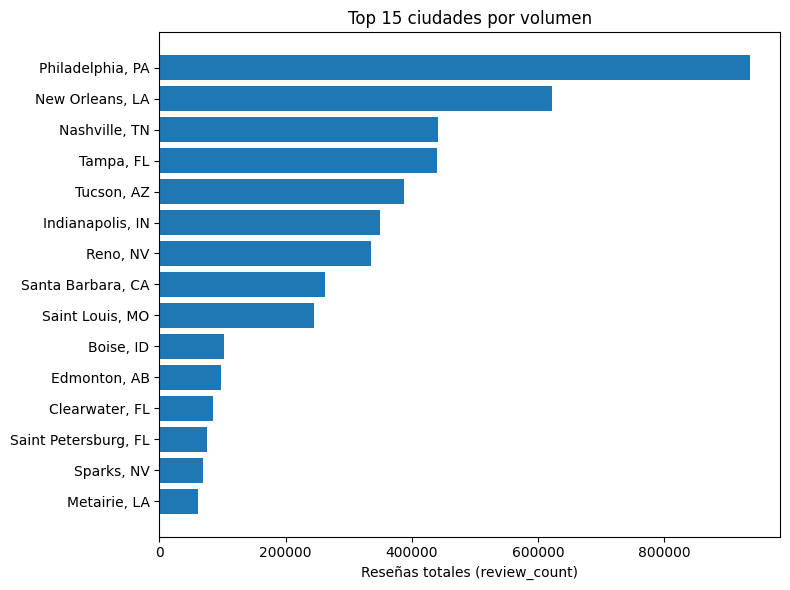

In [6]:
import matplotlib.pyplot as plt

top = city.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top['city_norm'] + ', ' + top['state'], top['total_reviews'])
ax.set_xlabel('Reseñas totales (review_count)')
ax.set_title('Top 15 ciudades por volumen')
plt.tight_layout(); plt.show()

In [7]:
from collections import Counter

# business_id -> "Ciudad, ST"
biz_city = dict(zip(biz['business_id'], biz['city_norm'] + ', ' + biz['state']))

counts, n = Counter(), 0
with open(REVIEW) as fh:
    for line in fh:                       # una línea (reseña) a la vez
        o = json.loads(line)
        c = biz_city.get(o['business_id'])
        if c:
            counts[c] += 1
        n += 1
        if n % 1_000_000 == 0:
            print(f'{n:,} reseñas...')

print(f'\nTotal en review.json: {n:,}')
rc = pd.Series(counts).sort_values(ascending=False)
rc.head(20)

1,000,000 reseñas...
2,000,000 reseñas...
3,000,000 reseñas...
4,000,000 reseñas...
5,000,000 reseñas...
6,000,000 reseñas...

Total en review.json: 6,990,280


Philadelphia, PA        967871
New Orleans, LA         635521
Tampa, FL               455463
Nashville, TN           451727
Tucson, AZ              405287
Indianapolis, IN        361584
Reno, NV                351737
Santa Barbara, CA       269740
Saint Louis, MO         253499
Boise, ID               105426
Edmonton, AB            101894
Clearwater, FL           87591
Saint Petersburg, FL     78932
Sparks, NV               73037
Metairie, LA             64420
St. Louis, MO            63477
Franklin, TN             56723
St. Petersburg, FL       54541
Goleta, CA               45643
Wilmington, DE           44882
dtype: int64

In [8]:
sweet = rc[(rc >= 50_000) & (rc <= 300_000)]
print('Ciudades con volumen rico pero tratable:\n')
print(sweet)

Ciudades con volumen rico pero tratable:

Santa Barbara, CA       269740
Saint Louis, MO         253499
Boise, ID               105426
Edmonton, AB            101894
Clearwater, FL           87591
Saint Petersburg, FL     78932
Sparks, NV               73037
Metairie, LA             64420
St. Louis, MO            63477
Franklin, TN             56723
St. Petersburg, FL       54541
dtype: int64


In [26]:
%%writefile config.py

import os
import glob

CITY = "Boise"
STATE = "ID"
CITY_LABEL = f"{CITY}, {STATE}"

DATA_ROOT = "/kaggle/input"

def _find_raw(keyword):
    m = glob.glob(os.path.join(DATA_ROOT, f"**/*{keyword}*.json"), recursive=True)
    return m[0] if m else None

BUSINESS = _find_raw("business")
REVIEW   = _find_raw("review")
USER     = _find_raw("user")
CHECKIN  = _find_raw("checkin")
TIP      = _find_raw("tip")

def _locate_artifacts():
    local = "/kaggle/working/artifacts"
    if glob.glob(os.path.join(local, "*.parquet")):
        return local
    for h in glob.glob("/kaggle/input/**/artifacts", recursive=True):
        if glob.glob(os.path.join(h, "*.parquet")):
            return h
    os.makedirs(local, exist_ok=True)
    return local

ARTIFACTS = _locate_artifacts()

MIN_USERS = 3000
MIN_LCC_FRACTION = 0.20
MIN_AVG_DEGREE = 1.0


def city_match(raw_city):
    return (raw_city or "").strip().title() == CITY

Overwriting config.py


In [10]:
%%writefile friendship_check.py

import json
from collections import Counter
import config


def _city_business_ids():
    ids = set()
    with open(config.BUSINESS) as fh:
        for line in fh:
            o = json.loads(line)
            if config.city_match(o.get("city")) and o.get("state") == config.STATE:
                ids.add(o["business_id"])
    return ids


def _city_users(business_ids):
    users, n = set(), 0
    with open(config.REVIEW) as fh:
        for line in fh:
            o = json.loads(line)
            if o.get("business_id") in business_ids:
                users.add(o["user_id"])
            n += 1
            if n % 1_000_000 == 0:
                print(f"     ...{n:,} resenas escaneadas")
    print(f"     resenas totales: {n:,}")
    return users


def _induced_graph(city_users):
    adj = {u: [] for u in city_users}
    no_friends, n = 0, 0
    with open(config.USER) as fh:
        for line in fh:
            o = json.loads(line)
            uid = o.get("user_id")
            n += 1
            if uid not in city_users:
                continue
            raw = (o.get("friends") or "").strip()
            if raw in ("", "None"):
                no_friends += 1
                continue
            for f in raw.split(","):
                f = f.strip()
                if f in city_users:
                    adj[uid].append(f)
            if n % 1_000_000 == 0:
                print(f"     ...{n:,} usuarios escaneados")
    return adj, no_friends


def _largest_component(adj):
    parent = {u: u for u in adj}

    def find(x):
        root = x
        while parent[root] != root:
            root = parent[root]
        while parent[x] != root:
            parent[x], x = root, parent[x]
        return root

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for u, friends in adj.items():
        for v in friends:
            union(u, v)

    sizes = Counter(find(u) for u in adj)
    return max(sizes.values()) if sizes else 0


def run_check():
    print(f"Chequeo de red de amistad -- {config.CITY_LABEL}\n")

    print("1/3  Negocios de la ciudad...")
    biz_ids = _city_business_ids()
    print(f"     {len(biz_ids):,} negocios en {config.CITY_LABEL}\n")

    print("2/3  Usuarios del mercado (streaming review.json)...")
    users = _city_users(biz_ids)
    print(f"     {len(users):,} usuarios distintos\n")

    print("3/3  Grafo de amistad inducido (streaming user.json)...")
    adj, no_friends = _induced_graph(users)

    n = len(adj)
    deg_sum = sum(len(v) for v in adj.values())
    edges = deg_sum // 2
    connected = sum(1 for v in adj.values() if v)
    isolated = n - connected
    avg_degree = deg_sum / n if n else 0
    density = deg_sum / (n * (n - 1)) if n > 1 else 0
    lcc = _largest_component(adj)
    lcc_frac = lcc / n if n else 0

    p = (lambda x: f"{x:.1%}") if n else (lambda x: "n/a")
    print("\n" + "=" * 52)
    print(f"RESULTADOS -- {config.CITY_LABEL}")
    print("=" * 52)
    print(f"Usuarios (nodos):                {n:,}")
    print(f"Aristas de amistad (intra):      {edges:,}")
    print(f"Sin amigos en todo Yelp:         {no_friends:,}  ({p(no_friends / n if n else 0)})")
    print(f"Conectados dentro de la ciudad:  {connected:,}  ({p(connected / n if n else 0)})")
    print(f"Aislados dentro de la ciudad:    {isolated:,}  ({p(isolated / n if n else 0)})")
    print(f"Grado promedio:                  {avg_degree:.2f}")
    print(f"Densidad:                        {density:.2e}")
    print(f"Componente conexa mayor (LCC):   {lcc:,}  ({p(lcc_frac)} de los nodos)")

    viable = (n >= config.MIN_USERS
              and lcc_frac >= config.MIN_LCC_FRACTION
              and avg_degree >= config.MIN_AVG_DEGREE)
    print("\n" + ("VEREDICTO: VIABLE -- la red social da para la Parte II."
                  if viable else
                  "VEREDICTO: DEBIL -- conviene mirar el LCC antes de decidir."))
    print(f"(Guia: usuarios >= {config.MIN_USERS}, "
          f"LCC >= {config.MIN_LCC_FRACTION:.0%}, grado prom. >= {config.MIN_AVG_DEGREE})")

    return dict(n_users=n, edges=edges, no_friends=no_friends, isolated=isolated,
                avg_degree=avg_degree, density=density, lcc=lcc,
                lcc_frac=lcc_frac, viable=viable)

Writing friendship_check.py


In [11]:
import importlib, config, friendship_check
importlib.reload(config); importlib.reload(friendship_check)
stats = friendship_check.run_check()

Chequeo de red de amistad -- Boise, ID

1/3  Negocios de la ciudad...
     2,941 negocios en Boise, ID

2/3  Usuarios del mercado (streaming review.json)...
     ...1,000,000 resenas escaneadas
     ...2,000,000 resenas escaneadas
     ...3,000,000 resenas escaneadas
     ...4,000,000 resenas escaneadas
     ...5,000,000 resenas escaneadas
     ...6,000,000 resenas escaneadas
     resenas totales: 6,990,280
     43,934 usuarios distintos

3/3  Grafo de amistad inducido (streaming user.json)...

RESULTADOS -- Boise, ID
Usuarios (nodos):                43,934
Aristas de amistad (intra):      37,264
Sin amigos en todo Yelp:         18,594  (42.3%)
Conectados dentro de la ciudad:  12,495  (28.4%)
Aislados dentro de la ciudad:    31,439  (71.6%)
Grado promedio:                  1.70
Densidad:                        3.86e-05
Componente conexa mayor (LCC):   11,233  (25.6% de los nodos)

VEREDICTO: VIABLE -- la red social da para la Parte II.
(Guia: usuarios >= 3000, LCC >= 20%, grado prom. >

# PARTE 1

In [12]:
%%writefile preprocessing.py
import os
import json
import pandas as pd
import config

_BIZ_FIELDS = ['business_id', 'name', 'address', 'city', 'state', 'postal_code',
               'latitude', 'longitude', 'stars', 'review_count', 'is_open',
               'attributes', 'categories', 'hours']
_REV_FIELDS = ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
               'cool', 'text', 'date']
_USER_FIELDS = ['user_id', 'name', 'review_count', 'yelping_since', 'useful',
                'funny', 'cool', 'fans', 'elite', 'average_stars']
_TIP_FIELDS = ['user_id', 'business_id', 'text', 'date', 'compliment_count']

P_BIZ      = os.path.join(config.ARTIFACTS, 'boise_business.parquet')
P_REVIEWS  = os.path.join(config.ARTIFACTS, 'boise_reviews.parquet')
P_USERS    = os.path.join(config.ARTIFACTS, 'boise_users.parquet')
P_CHECKINS = os.path.join(config.ARTIFACTS, 'boise_checkins.parquet')
P_TIPS     = os.path.join(config.ARTIFACTS, 'boise_tips.parquet')


def _stream(path):
    with open(path) as fh:
        for line in fh:
            yield json.loads(line)


def _business():
    rows = []
    for o in _stream(config.BUSINESS):
        if config.city_match(o.get('city')) and o.get('state') == config.STATE:
            rows.append({k: o.get(k) for k in _BIZ_FIELDS})
    df = pd.DataFrame(rows, columns=_BIZ_FIELDS)
    for col in ('attributes', 'hours'):
        df[col] = df[col].apply(
            lambda d: json.dumps(d, ensure_ascii=False) if d is not None else None)
    return df


def _reviews(biz_ids):
    rows, n = [], 0
    for o in _stream(config.REVIEW):
        if o.get('business_id') in biz_ids:
            rows.append({k: o.get(k) for k in _REV_FIELDS})
        n += 1
        if n % 1_000_000 == 0:
            print(f'     ...{n:,} resenas escaneadas')
    print(f'     resenas escaneadas en total: {n:,}')
    df = pd.DataFrame(rows, columns=_REV_FIELDS)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    return df


def _users(user_ids):
    rows, n = [], 0
    for o in _stream(config.USER):
        n += 1
        uid = o.get('user_id')
        if uid not in user_ids:
            continue
        rec = {k: o.get(k) for k in _USER_FIELDS}
        raw = (o.get('friends') or '').strip()
        all_friends = [] if raw in ('', 'None') else [f.strip() for f in raw.split(',')]
        boise_friends = [f for f in all_friends if f in user_ids]
        rec['n_friends_total'] = len(all_friends)
        rec['n_friends_boise'] = len(boise_friends)
        rec['friends_boise'] = ','.join(boise_friends)
        rows.append(rec)
        if n % 1_000_000 == 0:
            print(f'     ...{n:,} usuarios escaneados')
    cols = _USER_FIELDS + ['n_friends_total', 'n_friends_boise', 'friends_boise']
    df = pd.DataFrame(rows, columns=cols)
    df['yelping_since'] = pd.to_datetime(df['yelping_since'], errors='coerce')
    return df


def _filter_by_business(path, biz_ids, fields):
    rows = []
    for o in _stream(path):
        if o.get('business_id') in biz_ids:
            rows.append({k: o.get(k) for k in fields})
    return pd.DataFrame(rows, columns=fields)


def build_boise_subset():
    print(f'Construyendo el subconjunto de {config.CITY_LABEL}\n')

    print('1/5  Negocios...')
    biz = _business()
    biz_ids = set(biz['business_id'])
    biz.to_parquet(P_BIZ, index=False)
    print(f'     {len(biz):,} negocios -> {P_BIZ}\n')

    print('2/5  Resenas (streaming review.json, ~2 min)...')
    rev = _reviews(biz_ids)
    user_ids = set(rev['user_id'])
    rev.to_parquet(P_REVIEWS, index=False)
    print(f'     {len(rev):,} resenas, {len(user_ids):,} usuarios distintos -> {P_REVIEWS}\n')

    print('3/5  Usuarios (streaming user.json)...')
    usr = _users(user_ids)
    usr.to_parquet(P_USERS, index=False)
    print(f'     {len(usr):,} usuarios -> {P_USERS}\n')

    print('4/5  Check-ins...')
    chk = _filter_by_business(config.CHECKIN, biz_ids, ['business_id', 'date'])
    chk.to_parquet(P_CHECKINS, index=False)
    print(f'     {len(chk):,} negocios con check-ins -> {P_CHECKINS}\n')

    print('5/5  Tips...')
    tips = _filter_by_business(config.TIP, biz_ids, _TIP_FIELDS)
    tips.to_parquet(P_TIPS, index=False)

Writing preprocessing.py


In [13]:
import importlib, config, preprocessing
importlib.reload(config); importlib.reload(preprocessing)

data = preprocessing.build_boise_subset()

print('\n--- shapes ---')
for k, df in data.items():
    print(f'{k:9s}: {df.shape}')
data['business'].head()

Construyendo el subconjunto de Boise, ID

1/5  Negocios...
     2,941 negocios -> /kaggle/working/artifacts/boise_business.parquet

2/5  Resenas (streaming review.json, ~2 min)...
     ...1,000,000 resenas escaneadas
     ...2,000,000 resenas escaneadas
     ...3,000,000 resenas escaneadas
     ...4,000,000 resenas escaneadas
     ...5,000,000 resenas escaneadas
     ...6,000,000 resenas escaneadas
     resenas escaneadas en total: 6,990,280
     105,426 resenas, 43,934 usuarios distintos -> /kaggle/working/artifacts/boise_reviews.parquet

3/5  Usuarios (streaming user.json)...
     43,934 usuarios -> /kaggle/working/artifacts/boise_users.parquet

4/5  Check-ins...
     2,474 negocios con check-ins -> /kaggle/working/artifacts/boise_checkins.parquet

5/5  Tips...

--- shapes ---


AttributeError: 'NoneType' object has no attribute 'items'

In [14]:
%%writefile preprocessing.py
import os
import json
import pandas as pd
import config

_BIZ_FIELDS = ['business_id', 'name', 'address', 'city', 'state', 'postal_code',
               'latitude', 'longitude', 'stars', 'review_count', 'is_open',
               'attributes', 'categories', 'hours']
_REV_FIELDS = ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
               'cool', 'text', 'date']
_USER_FIELDS = ['user_id', 'name', 'review_count', 'yelping_since', 'useful',
                'funny', 'cool', 'fans', 'elite', 'average_stars']
_TIP_FIELDS = ['user_id', 'business_id', 'text', 'date', 'compliment_count']

P_BIZ      = os.path.join(config.ARTIFACTS, 'boise_business.parquet')
P_REVIEWS  = os.path.join(config.ARTIFACTS, 'boise_reviews.parquet')
P_USERS    = os.path.join(config.ARTIFACTS, 'boise_users.parquet')
P_CHECKINS = os.path.join(config.ARTIFACTS, 'boise_checkins.parquet')
P_TIPS     = os.path.join(config.ARTIFACTS, 'boise_tips.parquet')


def _stream(path):
    with open(path) as fh:
        for line in fh:
            yield json.loads(line)


def _business():
    rows = []
    for o in _stream(config.BUSINESS):
        if config.city_match(o.get('city')) and o.get('state') == config.STATE:
            rows.append({k: o.get(k) for k in _BIZ_FIELDS})
    df = pd.DataFrame(rows, columns=_BIZ_FIELDS)
    for col in ('attributes', 'hours'):
        df[col] = df[col].apply(
            lambda d: json.dumps(d, ensure_ascii=False) if d is not None else None)
    return df


def _reviews(biz_ids):
    rows, n = [], 0
    for o in _stream(config.REVIEW):
        if o.get('business_id') in biz_ids:
            rows.append({k: o.get(k) for k in _REV_FIELDS})
        n += 1
        if n % 1_000_000 == 0:
            print(f'     ...{n:,} resenas escaneadas')
    print(f'     resenas escaneadas en total: {n:,}')
    df = pd.DataFrame(rows, columns=_REV_FIELDS)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    return df


def _users(user_ids):
    rows, n = [], 0
    for o in _stream(config.USER):
        n += 1
        uid = o.get('user_id')
        if uid not in user_ids:
            continue
        rec = {k: o.get(k) for k in _USER_FIELDS}
        raw = (o.get('friends') or '').strip()
        all_friends = [] if raw in ('', 'None') else [f.strip() for f in raw.split(',')]
        boise_friends = [f for f in all_friends if f in user_ids]
        rec['n_friends_total'] = len(all_friends)
        rec['n_friends_boise'] = len(boise_friends)
        rec['friends_boise'] = ','.join(boise_friends)
        rows.append(rec)
        if n % 1_000_000 == 0:
            print(f'     ...{n:,} usuarios escaneados')
    cols = _USER_FIELDS + ['n_friends_total', 'n_friends_boise', 'friends_boise']
    df = pd.DataFrame(rows, columns=cols)
    df['yelping_since'] = pd.to_datetime(df['yelping_since'], errors='coerce')
    return df


def _filter_by_business(path, biz_ids, fields):
    rows = []
    for o in _stream(path):
        if o.get('business_id') in biz_ids:
            rows.append({k: o.get(k) for k in fields})
    return pd.DataFrame(rows, columns=fields)


def build_boise_subset(rebuild=False):
    print(f'Construyendo el subconjunto de {config.CITY_LABEL}'
          f'{"  (rebuild=True)" if rebuild else ""}\n')

    if not rebuild and os.path.exists(P_BIZ):
        biz = pd.read_parquet(P_BIZ)
        print(f'1/5  Negocios: cache ({len(biz):,})')
    else:
        print('1/5  Negocios...')
        biz = _business()
        biz.to_parquet(P_BIZ, index=False)
        print(f'     {len(biz):,} negocios -> {P_BIZ}')
    biz_ids = set(biz['business_id'])

    if not rebuild and os.path.exists(P_REVIEWS):
        rev = pd.read_parquet(P_REVIEWS)
        print(f'2/5  Resenas: cache ({len(rev):,})')
    else:
        print('2/5  Resenas (streaming review.json, ~2 min)...')
        rev = _reviews(biz_ids)
        rev.to_parquet(P_REVIEWS, index=False)
        print(f'     {len(rev):,} resenas -> {P_REVIEWS}')
    user_ids = set(rev['user_id'])

    if not rebuild and os.path.exists(P_USERS):
        usr = pd.read_parquet(P_USERS)
        print(f'3/5  Usuarios: cache ({len(usr):,})')
    else:
        print('3/5  Usuarios (streaming user.json)...')
        usr = _users(user_ids)
        usr.to_parquet(P_USERS, index=False)
        print(f'     {len(usr):,} usuarios -> {P_USERS}')

    if not rebuild and os.path.exists(P_CHECKINS):
        print('4/5  Check-ins: cache')
    else:
        print('4/5  Check-ins...')
        chk = _filter_by_business(config.CHECKIN, biz_ids, ['business_id', 'date'])
        chk.to_parquet(P_CHECKINS, index=False)
        print(f'     {len(chk):,} negocios con check-ins -> {P_CHECKINS}')

    if not rebuild and os.path.exists(P_TIPS):
        print('5/5  Tips: cache')
    else:
        print('5/5  Tips...')
        tips = _filter_by_business(config.TIP, biz_ids, _TIP_FIELDS)
        tips.to_parquet(P_TIPS, index=False)
        print(f'     {len(tips):,} tips -> {P_TIPS}')

    print(f'\nListo. Subconjunto de Boise en {config.ARTIFACTS}')
    return load_subset()


def load_subset():
    return {
        'business': pd.read_parquet(P_BIZ),
        'reviews':  pd.read_parquet(P_REVIEWS),
        'users':    pd.read_parquet(P_USERS),
        'checkins': pd.read_parquet(P_CHECKINS),
        'tips':     pd.read_parquet(P_TIPS),
    }


if __name__ == '__main__':
    build_boise_subset()

Overwriting preprocessing.py


In [15]:
import importlib, config, preprocessing
importlib.reload(config); importlib.reload(preprocessing)

assert hasattr(preprocessing, 'load_subset'), 'El archivo se copio incompleto; revisa la Celda 1.'

data = preprocessing.build_boise_subset()

print('\n--- shapes ---')
for k, df in data.items():
    print(f'{k:9s}: {df.shape}')
data['business'].head()

Construyendo el subconjunto de Boise, ID

1/5  Negocios: cache (2,941)
2/5  Resenas: cache (105,426)
3/5  Usuarios: cache (43,934)
4/5  Check-ins: cache
5/5  Tips: cache

Listo. Subconjunto de Boise en /kaggle/working/artifacts

--- shapes ---
business : (2941, 14)
reviews  : (105426, 9)
users    : (43934, 13)
checkins : (2474, 2)
tips     : (11436, 5)


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,fvWn8oXXwbj2l79cochZyw,Altitude Trampoline Park - Boise,1301 N Milwaukee St,Boise,ID,83704,43.616763,-116.285382,5.0,30,1,"{""BusinessParking"": ""{'garage': False, 'street...","Trampoline Parks, Active Life","{""Monday"": ""10:0-20:0"", ""Tuesday"": ""10:0-20:0""..."
1,Fk1xpM7fjqEJ4paqk5ZFSg,Jamba Juice,"13601 W Mcmillan Rd, Ste 103",Boise,ID,83713,43.647832,-116.352071,3.0,19,0,"{""BusinessParking"": ""None"", ""RestaurantsPriceR...","Juice Bars & Smoothies, Food","{""Monday"": ""0:0-0:0"", ""Tuesday"": ""7:0-22:0"", ""..."
2,t5tBd4p7BA7hNDitBUXxrw,Boise Therapeutic Massage Center,7153 W Emerald St,Boise,ID,83704,43.611949,-116.271110,4.0,68,1,"{""WheelchairAccessible"": ""True"", ""BusinessAcce...","Massage, Health & Medical, Medical Spas, Beaut...","{""Monday"": ""9:0-21:0"", ""Tuesday"": ""9:0-21:0"", ..."
3,3S9GYtMOYhbZl4MMPOHT0Q,The Handlebar Boise,1519 W Main St,Boise,ID,83702,43.620010,-116.212790,4.5,34,1,"{""RestaurantsPriceRange2"": ""1"", ""RestaurantsGo...","Bars, Wine Bars, Nightlife, Beer Bar","{""Monday"": ""0:0-0:0"", ""Tuesday"": ""14:0-22:0"", ..."
4,CWE-NfyMgi28ePUiansSdQ,Jim's Appliance & Furniture,1115 Lusk St,Boise,ID,83706,43.607258,-116.212730,3.5,24,1,"{""RestaurantsPriceRange2"": ""2"", ""BusinessAccep...","Appliances, Mattresses, Shopping, Home & Garden","{""Monday"": ""9:0-18:0"", ""Tuesday"": ""9:0-18:0"", ..."


### Cleaning

In [16]:
%%writefile cleaning.py
import ast
import json
import pandas as pd
import config
import preprocessing


def _parse_categories(s):
    if not s or (isinstance(s, float) and pd.isna(s)):
        return []
    return [c.strip() for c in str(s).split(',') if c.strip()]


def _coerce_value(v):
    if v is None or isinstance(v, bool):
        return v
    s = str(v).strip()
    if s in ('None', ''):
        return None
    if s == 'True':
        return True
    if s == 'False':
        return False
    if s.startswith('{') and s.endswith('}'):
        try:
            return {k: _coerce_value(val) for k, val in ast.literal_eval(s).items()}
        except (ValueError, SyntaxError):
            return s
    if s.lstrip('-').isdigit():
        return int(s)
    return s


def _parse_attributes(s):
    if not s or (isinstance(s, float) and pd.isna(s)):
        return {}
    try:
        raw = json.loads(s)
    except (json.JSONDecodeError, TypeError):
        return {}
    return {k: _coerce_value(v) for k, v in raw.items()}


def _parse_hours_count(s):
    if not s or (isinstance(s, float) and pd.isna(s)):
        return 0
    try:
        return len(json.loads(s))
    except (json.JSONDecodeError, TypeError):
        return 0


def clean_business(biz):
    rep, df, n0 = {}, biz.copy(), len(biz)
    df = df.drop_duplicates('business_id')
    rep['business_id duplicados eliminados'] = n0 - len(df)

    df['categories_list'] = df['categories'].apply(_parse_categories)
    df['n_categories'] = df['categories_list'].apply(len)
    rep['negocios sin categoria'] = int((df['n_categories'] == 0).sum())

    df['attributes_clean'] = df['attributes'].apply(_parse_attributes)
    df['price_range'] = df['attributes_clean'].apply(
        lambda d: d.get('RestaurantsPriceRange2') if isinstance(d, dict) else None)
    rep['negocios sin atributos'] = int((df['attributes_clean'].apply(len) == 0).sum())
    rep['negocios sin price_range'] = int(df['price_range'].isna().sum())

    df['n_days_open'] = df['hours'].apply(_parse_hours_count)
    rep['negocios sin horario'] = int((df['n_days_open'] == 0).sum())

    thr = df['review_count'].quantile(0.99)
    df['rc_outlier'] = df['review_count'] > thr
    rep[f'outliers review_count (>p99={thr:.0f}), marcados no eliminados'] = int(df['rc_outlier'].sum())
    return df, rep


def clean_reviews(rev):
    rep, df, n0 = {}, rev.copy(), len(rev)
    df = df.drop_duplicates('review_id')
    rep['review_id duplicados eliminados'] = n0 - len(df)

    n1 = len(df)
    df = df.sort_values('date').drop_duplicates(['user_id', 'business_id'], keep='last')
    rep['pares (user,business) repetidos colapsados al mas reciente'] = n1 - len(df)

    df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
    rep['reviews con stars invalido'] = int(df['stars'].isna().sum())

    df['text'] = df['text'].fillna('')
    df['text_len'] = df['text'].str.len()
    rep['reviews con texto vacio'] = int((df['text_len'] == 0).sum())
    return df, rep


def clean_users(usr):
    rep, df, n0 = {}, usr.copy(), len(usr)
    df = df.drop_duplicates('user_id')
    rep['user_id duplicados eliminados'] = n0 - len(df)

    elite = df['elite'].fillna('').astype(str)
    df['n_elite_years'] = elite.apply(
        lambda s: 0 if s.strip() in ('', 'None') else len([y for y in s.split(',') if y.strip()]))
    df['is_elite'] = df['n_elite_years'] > 0
    rep['usuarios elite'] = int(df['is_elite'].sum())

    thr = df['review_count'].quantile(0.99)
    df['rc_outlier'] = df['review_count'] > thr
    rep[f'outliers review_count (>p99={thr:.0f}), marcados no eliminados'] = int(df['rc_outlier'].sum())
    return df, rep


def clean_checkins(chk):
    df = chk.copy()
    df['n_checkins'] = df['date'].fillna('').apply(
        lambda s: 0 if not s else len(str(s).split(',')))
    return df, {'total check-ins contados': int(df['n_checkins'].sum())}


def clean_tips(tips):
    df, n0 = tips.copy(), len(tips)
    df = df.drop_duplicates()
    df['text'] = df['text'].fillna('')
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    return df, {'tips duplicados eliminados': n0 - len(df)}


def clean_subset(data=None):
    if data is None:
        data = preprocessing.load_subset()

    biz, r1 = clean_business(data['business'])
    rev, r2 = clean_reviews(data['reviews'])
    usr, r3 = clean_users(data['users'])
    chk, r4 = clean_checkins(data['checkins'])
    tip, r5 = clean_tips(data['tips'])

    print(f'REPORTE DE LIMPIEZA -- {config.CITY_LABEL}')
    for title, rep in [('Negocios', r1), ('Resenas', r2), ('Usuarios', r3),
                       ('Check-ins', r4), ('Tips', r5)]:
        print(f'\n[{title}]')
        for k, v in rep.items():
            print(f'  - {k}: {v:,}' if isinstance(v, int) else f'  - {k}: {v}')

    print('\nFilas tras limpieza:')
    for k, df in [('business', biz), ('reviews', rev), ('users', usr),
                  ('checkins', chk), ('tips', tip)]:
        print(f'  {k:9s}: {len(df):,}')

    return {'business': biz, 'reviews': rev, 'users': usr,
            'checkins': chk, 'tips': tip}

Writing cleaning.py


In [17]:
import importlib, config, preprocessing, cleaning
importlib.reload(config); importlib.reload(preprocessing); importlib.reload(cleaning)

assert hasattr(cleaning, 'clean_subset'), 'cleaning.py se copio incompleto; revisa la Celda 1.'

clean = cleaning.clean_subset()
clean['business'][['name', 'categories_list', 'price_range', 'n_days_open', 'rc_outlier']].head()

REPORTE DE LIMPIEZA -- Boise, ID

[Negocios]
  - business_id duplicados eliminados: 0
  - negocios sin categoria: 3
  - negocios sin atributos: 264
  - negocios sin price_range: 1,366
  - negocios sin horario: 412
  - outliers review_count (>p99=325), marcados no eliminados: 30

[Resenas]
  - review_id duplicados eliminados: 0
  - pares (user,business) repetidos colapsados al mas reciente: 3,471
  - reviews con stars invalido: 0
  - reviews con texto vacio: 0

[Usuarios]
  - user_id duplicados eliminados: 0
  - usuarios elite: 2,589
  - outliers review_count (>p99=486), marcados no eliminados: 439

[Check-ins]
  - total check-ins contados: 154,145

[Tips]
  - tips duplicados eliminados: 0

Filas tras limpieza:
  business : 2,941
  reviews  : 101,955
  users    : 43,934
  checkins : 2,474
  tips     : 11,436


,name,categories_list,price_range,n_days_open,rc_outlier
0,Altitude Trampoline Park - Boise,"[Trampoline Parks, Active Life]",NaN,7,False
1,Jamba Juice,"[Juice Bars & Smoothies, Food]",1.0,7,False
2,Boise Therapeutic Massage Center,"[Massage, Health & Medical, Medical Spas, Beau...",2.0,7,False
3,The Handlebar Boise,"[Bars, Wine Bars, Nightlife, Beer Bar]",1.0,7,False
4,Jim's Appliance & Furniture,"[Appliances, Mattresses, Shopping, Home & Garden]",2.0,6,False


### EDA

In [18]:
%%writefile eda.py
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config


def plot_rating_distribution(clean):
    rev = clean['reviews']
    counts = rev['stars'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(counts.index, counts.values, width=0.6, color='#378ADD')
    ax.set_xlabel('Estrellas'); ax.set_ylabel('Nro de resenas')
    ax.set_title(f'Distribucion de ratings -- {config.CITY_LABEL}')
    for x, y in zip(counts.index, counts.values):
        ax.text(x, y, f'{y:,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()
    print(f'Rating promedio: {rev["stars"].mean():.2f} (sesgo a 4-5, tipico de Yelp)')


def plot_review_length(clean):
    rev = clean['reviews']
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(rev['text_len'].clip(upper=2000), bins=50, color='#1D9E75')
    ax.set_xlabel('Longitud de resena (caracteres, recortado a 2000)')
    ax.set_ylabel('Nro de resenas')
    ax.set_title('Distribucion de longitud de resenas')
    plt.tight_layout(); plt.show()
    print(f'Mediana de longitud: {rev["text_len"].median():.0f} caracteres')


def _loglog(series, ax, xlabel, color):
    vc = series.value_counts().sort_index()
    vc = vc[vc.index > 0]
    ax.scatter(vc.index, vc.values, s=12, color=color, alpha=0.6)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(xlabel); ax.set_ylabel('Frecuencia (nro de elementos)')


def plot_powerlaws(clean):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    _loglog(clean['business']['review_count'], axes[0],
            'Resenas por negocio', '#D85A30')
    axes[0].set_title('Power-law: actividad de negocios')
    per_user = clean['reviews']['user_id'].value_counts()
    _loglog(per_user, axes[1], 'Resenas por usuario (en Boise)', '#534AB7')
    axes[1].set_title('Power-law: actividad de usuarios')
    plt.tight_layout(); plt.show()
    print('Ambas siguen ley de potencias: pocos muy activos, larga cola de casuales.')


def plot_top_categories(clean, top=15):
    cats = Counter()
    for lst in clean['business']['categories_list']:
        cats.update(lst)
    common = pd.Series(dict(cats.most_common(top))).iloc[::-1]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(common.index, common.values, color='#378ADD')
    ax.set_xlabel('Nro de negocios')
    ax.set_title(f'Top {top} categorias -- {config.CITY_LABEL}')
    plt.tight_layout(); plt.show()


def plot_geographic(clean):
    biz = clean['business']
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(biz['longitude'], biz['latitude'], c=biz['stars'],
                    cmap='viridis', s=14, alpha=0.6)
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    ax.set_title(f'Negocios de {config.CITY_LABEL} (color = estrellas)')
    fig.colorbar(sc, ax=ax, label='Estrellas')
    plt.tight_layout(); plt.show()


def plot_temporal(clean):
    rev = clean['reviews'].dropna(subset=['date'])
    monthly = rev.set_index('date').resample('MS').size()
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(monthly.index, monthly.values, color='#0F6E56')
    ax.set_xlabel('Fecha'); ax.set_ylabel('Resenas por mes')
    ax.set_title('Evolucion temporal de resenas')
    plt.tight_layout(); plt.show()


def plot_friendship_degree(clean):
    deg = clean['users']['n_friends_boise']
    fig, ax = plt.subplots(figsize=(6, 4))
    _loglog(deg[deg > 0], ax, 'Amigos dentro de Boise (grado)', '#993556')
    ax.set_title('Distribucion de grados del grafo de amistad')
    plt.tight_layout(); plt.show()
    print(f'{(deg == 0).mean():.1%} de usuarios sin amigos en Boise; '
          f'el resto forma el nucleo social de la Parte II.')


def plot_segments(clean):
    biz, usr = clean['business'], clean['users']
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    by_open = biz.groupby('is_open')['stars'].mean()
    axes[0].bar(['Cerrado', 'Abierto'],
                [by_open.get(0, np.nan), by_open.get(1, np.nan)],
                color=['#888780', '#1D9E75'])
    axes[0].set_ylabel('Estrellas promedio')
    axes[0].set_title('Rating: abierto vs cerrado')
    by_elite = usr.groupby('is_elite')['average_stars'].mean()
    axes[1].bar(['No elite', 'Elite'],
                [by_elite.get(False, np.nan), by_elite.get(True, np.nan)],
                color=['#888780', '#534AB7'])
    axes[1].set_ylabel('Estrellas promedio dadas')
    axes[1].set_title('Comportamiento: elite vs no elite')
    plt.tight_layout(); plt.show()


def plot_all(clean):
    plot_rating_distribution(clean)
    plot_review_length(clean)
    plot_powerlaws(clean)
    plot_top_categories(clean)
    plot_geographic(clean)
    plot_temporal(clean)
    plot_friendship_degree(clean)
    plot_segments(clean)

Writing eda.py


REPORTE DE LIMPIEZA -- Boise, ID

[Negocios]
  - business_id duplicados eliminados: 0
  - negocios sin categoria: 3
  - negocios sin atributos: 264
  - negocios sin price_range: 1,366
  - negocios sin horario: 412
  - outliers review_count (>p99=325), marcados no eliminados: 30

[Resenas]
  - review_id duplicados eliminados: 0
  - pares (user,business) repetidos colapsados al mas reciente: 3,471
  - reviews con stars invalido: 0
  - reviews con texto vacio: 0

[Usuarios]
  - user_id duplicados eliminados: 0
  - usuarios elite: 2,589
  - outliers review_count (>p99=486), marcados no eliminados: 439

[Check-ins]
  - total check-ins contados: 154,145

[Tips]
  - tips duplicados eliminados: 0

Filas tras limpieza:
  business : 2,941
  reviews  : 101,955
  users    : 43,934
  checkins : 2,474
  tips     : 11,436


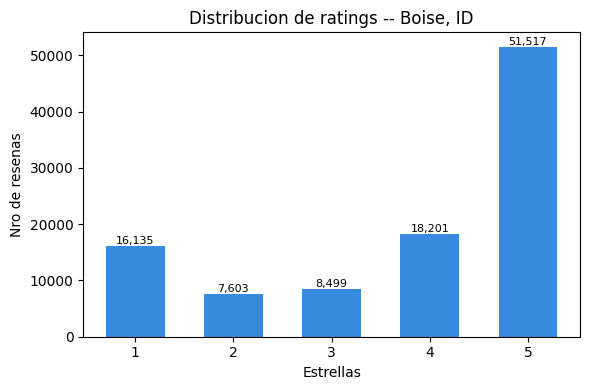

Rating promedio: 3.80 (sesgo a 4-5, tipico de Yelp)


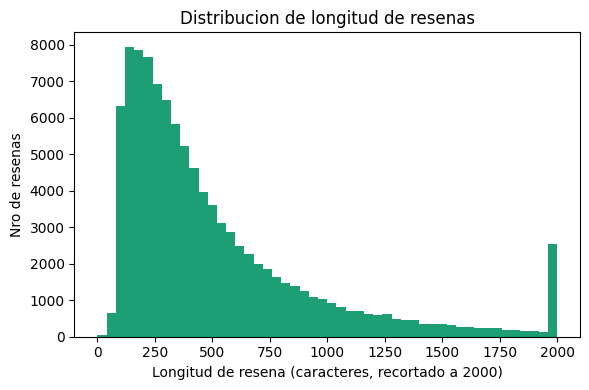

Mediana de longitud: 369 caracteres


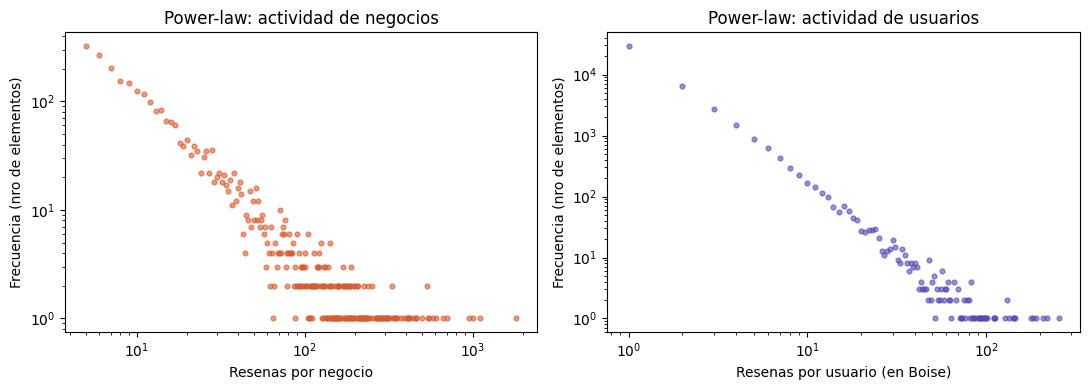

Ambas siguen ley de potencias: pocos muy activos, larga cola de casuales.


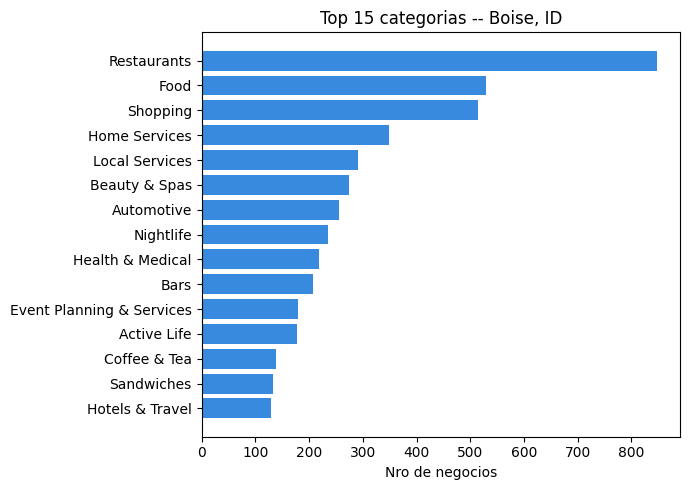

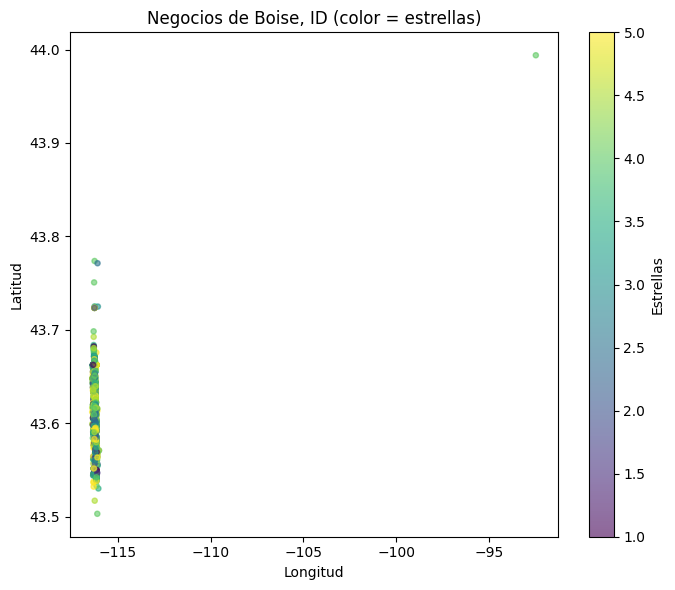

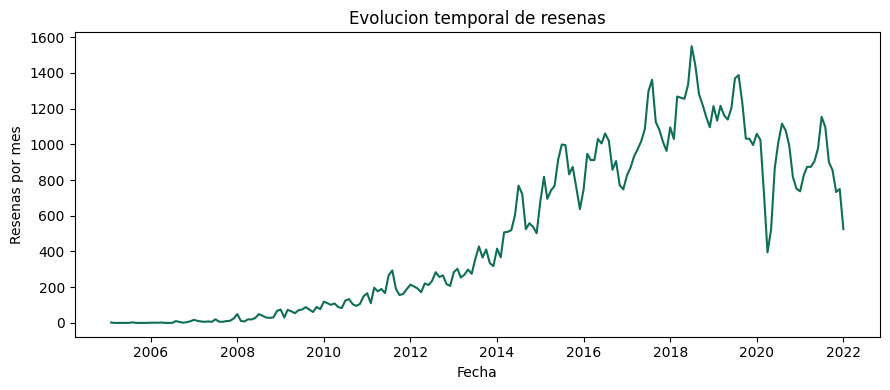

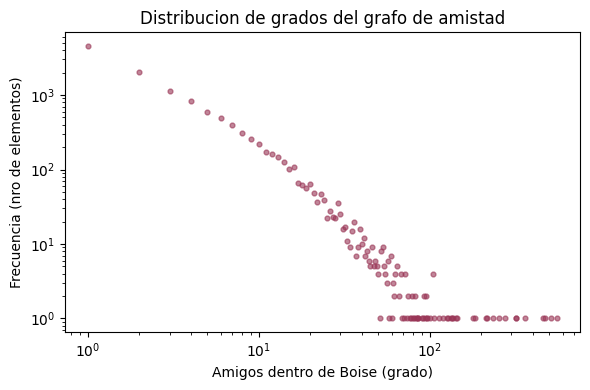

71.6% de usuarios sin amigos en Boise; el resto forma el nucleo social de la Parte II.


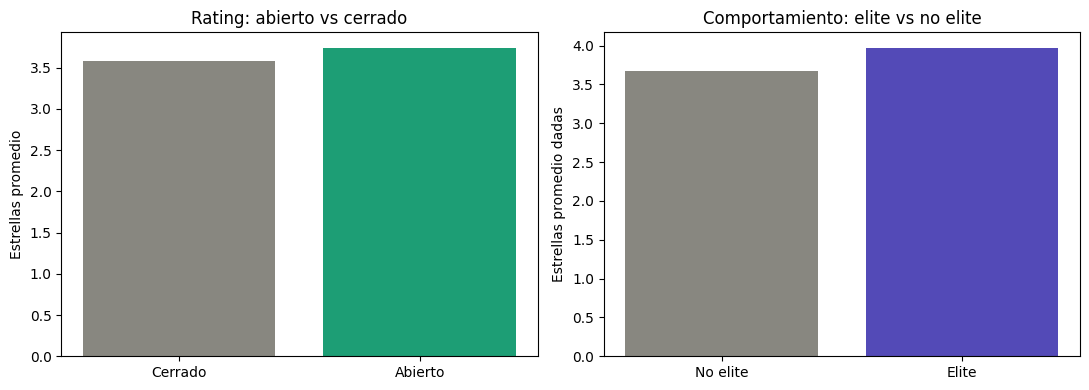

In [19]:
import importlib, config, preprocessing, cleaning, eda
importlib.reload(eda)

clean = cleaning.clean_subset() 
eda.plot_all(clean)

### Gráficos

In [22]:
%%writefile graphs.py
from collections import deque
import config


def build_bipartite(reviews):
    n_users = reviews['user_id'].nunique()
    n_biz = reviews['business_id'].nunique()
    n_edges = len(reviews)
    density = n_edges / (n_users * n_biz) if n_users and n_biz else 0
    return {'n_users': n_users, 'n_business': n_biz,
            'n_edges': n_edges, 'density': density}


def build_friendship(users):
    adj = {}
    for uid, fr in zip(users['user_id'], users['friends_boise']):
        adj.setdefault(uid, set())
        if isinstance(fr, str) and fr:
            for f in fr.split(','):
                if f:
                    adj[uid].add(f)
                    adj.setdefault(f, set()).add(uid)
    return adj


def _components(adj):
    seen, comps = set(), []
    for start in adj:
        if start in seen:
            continue
        comp, dq = [], deque([start])
        seen.add(start)
        while dq:
            u = dq.popleft()
            comp.append(u)
            for v in adj[u]:
                if v not in seen:
                    seen.add(v)
                    dq.append(v)
        comps.append(comp)
    return comps


def _bfs_farthest(adj, src):
    dist = {src: 0}
    dq = deque([src])
    far, fd = src, 0
    while dq:
        u = dq.popleft()
        for v in adj[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                if dist[v] > fd:
                    far, fd = v, dist[v]
                dq.append(v)
    return far, fd


def approx_diameter(adj, lcc_set):
    sub = {u: (adj[u] & lcc_set) for u in lcc_set}
    a, _ = _bfs_farthest(sub, next(iter(lcc_set)))
    _, d = _bfs_farthest(sub, a)
    return d


def friendship_metrics(users):
    adj = build_friendship(users)
    n = len(adj)
    deg_sum = sum(len(v) for v in adj.values())
    edges = deg_sum // 2
    density = deg_sum / (n * (n - 1)) if n > 1 else 0
    comps = _components(adj)
    lcc = max(comps, key=len) if comps else []
    diam = approx_diameter(adj, set(lcc)) if lcc else 0
    metrics = {'n_nodes': n, 'n_edges': edges, 'density': density,
               'n_components': len(comps), 'lcc_size': len(lcc),
               'lcc_fraction': len(lcc) / n if n else 0,
               'lcc_diameter_approx': diam}
    return metrics, adj, lcc


def build_graphs(clean=None):
    if clean is None:
        import cleaning
        clean = cleaning.clean_subset()

    bp = build_bipartite(clean['reviews'])
    fm, adj, lcc = friendship_metrics(clean['users'])

    print(f'GRAFOS INICIALES -- {config.CITY_LABEL}\n')
    print('[Bipartito usuario-negocio]')
    print(f"  usuarios:          {bp['n_users']:,}")
    print(f"  negocios:          {bp['n_business']:,}")
    print(f"  aristas (reseñas): {bp['n_edges']:,}")
    print(f"  densidad:          {bp['density']:.2e}")
    print('\n[Amistad usuario-usuario]')
    print(f"  nodos:             {fm['n_nodes']:,}")
    print(f"  aristas:           {fm['n_edges']:,}")
    print(f"  densidad:          {fm['density']:.2e}")
    print(f"  componentes:       {fm['n_components']:,}")
    print(f"  LCC:               {fm['lcc_size']:,} ({fm['lcc_fraction']:.1%})")
    print(f"  diametro aprox LCC: {fm['lcc_diameter_approx']}")

    return {'bipartite': bp, 'friendship': fm, 'friend_adj': adj, 'lcc': lcc}

Overwriting graphs.py


In [25]:
import importlib, config, preprocessing, cleaning, graphs
importlib.reload(graphs)

clean = cleaning.clean_subset()
G = graphs.build_graphs(clean)

REPORTE DE LIMPIEZA -- Boise, ID

[Negocios]
  - business_id duplicados eliminados: 0
  - negocios sin categoria: 3
  - negocios sin atributos: 264
  - negocios sin price_range: 1,366
  - negocios sin horario: 412
  - outliers review_count (>p99=325), marcados no eliminados: 30

[Resenas]
  - review_id duplicados eliminados: 0
  - pares (user,business) repetidos colapsados al mas reciente: 3,471
  - reviews con stars invalido: 0
  - reviews con texto vacio: 0

[Usuarios]
  - user_id duplicados eliminados: 0
  - usuarios elite: 2,589
  - outliers review_count (>p99=486), marcados no eliminados: 439

[Check-ins]
  - total check-ins contados: 154,145

[Tips]
  - tips duplicados eliminados: 0

Filas tras limpieza:
  business : 2,941
  reviews  : 101,955
  users    : 43,934
  checkins : 2,474
  tips     : 11,436
GRAFOS INICIALES -- Boise, ID

[Bipartito usuario-negocio]
  usuarios:          43,934
  negocios:          2,941
  aristas (reseñas): 101,955
  densidad:          7.89e-04

[Amista